# Day 18 — Spatial Joins: PLUTO Lots to Census Block Groups

---

## What you're building

Days 13–17 grouped everything by **zip code** — 4 buckets for all of Bushwick. A zip code covers a huge, uneven area; averaging FAR gap or displacement risk across one zip code hides real variation block to block. Today you connect each individual PLUTO tax lot to a much smaller geography — the **Census block group** — using its actual latitude/longitude, not a shared zip code column.

## What a block group is

A **block group** is a Census Bureau geography, smaller than a zip code and a tract, roughly 600–3,000 people. It's the smallest geography the ACS reports data for reliably. Every block group has a unique **GEOID** — state FIPS + county FIPS + tract code + block group number, concatenated into one ID string.

## The new idea: spatial joins

Every merge you've done so far (Days 4, 9, 17) joined rows on a **shared key column** — a zip code, a BBL, a block/lot pair. Today's join has no shared column. Instead, you ask a geometric question: *does this point (a tax lot's lat/lon) fall inside this polygon (a block group's boundary)?* That's a **spatial join** — `geopandas.sjoin()` instead of `pandas.merge()`.

## CRS — the gotcha that will break this silently

A **CRS (Coordinate Reference System)** defines how a pair of numbers like `(40.70, -73.92)` maps onto an actual location on Earth. Two datasets can both use "latitude and longitude" and still disagree — NAD83 and WGS84 place the same coordinate pair slightly differently. If you spatial-join two GeoDataFrames with mismatched CRS, you won't get an error. You'll get silently wrong joins — points that look like they should fall inside a polygon, quietly landing outside it, or vice versa. Always check `.crs` on both GeoDataFrames and reproject one to match with `.to_crs()` before joining.

## How today is structured

- **Boilerplate** (downloading block group boundaries, imports, final map) — already written.
- **Data work** (building the PLUTO GeoDataFrame, aligning CRS, the spatial join itself, aggregating by block group) — your job.
- After each data cell, predict the output before running.


In [1]:
# CELL 1 — Imports. (Boilerplate.)
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

In [2]:
# CELL 2 — Download Census block group boundaries for Kings County (Brooklyn). (Boilerplate.)
#
# What this does: pulls the 2022 TIGER/Line block group shapefile for all of
# New York State directly from the Census Bureau (no API key needed — these
# are public geometry files, not the data API), then filters down to Kings
# County (Brooklyn), FIPS code 047.
#
# geopandas can read a zipped shapefile straight from a URL.

url = 'https://www2.census.gov/geo/tiger/TIGER2022/BG/tl_2022_36_bg.zip'
gdf_bg_ny = gpd.read_file(url)

gdf_bg = gdf_bg_ny[gdf_bg_ny['COUNTYFP'] == '047'].copy()

print(gdf_bg.shape)
print(gdf_bg[['GEOID', 'COUNTYFP', 'TRACTCE', 'BLKGRPCE']].head(3))
print(gdf_bg.crs)

(2156, 13)
           GEOID COUNTYFP TRACTCE BLKGRPCE
13  360470594031      047  059403        1
14  360470594032      047  059403        2
15  360470594042      047  059404        2
EPSG:4269


**Before Cell 3:** Two questions before you touch the geometry:

1. What CRS is `gdf_bg` in? Run `gdf_bg.crs` and see what it prints.
2. PLUTO's `latitude`/`longitude` columns are plain numbers in a DataFrame — not geometry yet. What do you need to construct before geopandas can treat a PLUTO row as a point in space?

GDF BG is in EPSG:4269 which is the North American Datum 1983 coordinate system. 

I need to convert that PLUTO dataset into a GeoDataFrame

In [3]:
# CELL 3 — Build a GeoDataFrame of Bushwick PLUTO lots.
#
# Steps:
#   1. Load pluto.csv, filter to df['community board'] == 304.0 (Bushwick).
#      Store as df_bw_pluto. Don't forget .copy().

df_pluto = pd.read_csv('../data/pluto.csv').copy()

df_bw_pluto = df_pluto[df_pluto['community board'] == 304.0]

df_bw_pluto['builtfar'] = pd.to_numeric(df_bw_pluto['builtfar'], errors='coerce')
df_bw_pluto['residfar'] = pd.to_numeric(df_bw_pluto['residfar'], errors='coerce')





#   2. Drop any rows where latitude or longitude is null — you can't place
#      a point with a missing coordinate. Check len() before and after.

df_bw_pluto= df_bw_pluto.dropna(subset=['latitude', 'longitude'])

#   3. Build a geometry column of Point objects:
geometry = [Point(xy) for xy in zip(df_bw_pluto['longitude'], df_bw_pluto['latitude'])]
#      Gotcha: Point(x, y) takes LONGITUDE FIRST, then latitude — backwards
#      from how you'd normally say a coordinate out loud.
#Wrap it in a GeoDataFrame
gdf_pluto = gpd.GeoDataFrame(df_bw_pluto, geometry=geometry, crs='EPSG:4326')
#      EPSG:4326 is the standard CRS code for plain WGS84 lat/lon — the one
#      GPS and most lat/lon columns use.
#   5. Reproject to match gdf_bg's CRS: gdf_pluto = gdf_pluto.to_crs(gdf_bg.crs)
#
# Sanity check: 
print(gdf_pluto.shape) and print(gdf_pluto.crs == gdf_bg.crs)

# TODO


/var/folders/01/7mmm8p_55mz_znpc8yd21gjc0000gn/T/ipykernel_8797/3687351985.py:7: DtypeWarning: Columns (0: zonedist3, 1: zonedist4, 2: overlay2, 3: spdist1, 4: spdist2, 5: ltdheight, 6: splitzone, 7: unitsres, 8: unitstotal, 9: lotfront, 10: lotdepth, 11: bldgfront, 12: bldgdepth, 13: irrlotcode, 14: histdist, 15: landmark, 16: condono, 17: edesignum, 18: dcpedited, 19: mihopt1, 20: mihopt2, 21: mihopt3, 22: mihopt4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pluto = pd.read_csv('../data/pluto.csv').copy()


(11154, 109)


**Before Cell 4:** `pd.merge()` joins rows where a column value matches exactly. `gpd.sjoin()` joins rows where a *geometric relationship* holds. What predicate do you think you'd pass to ask "does this lot's point fall inside this block group's polygon"? (Look at `gpd.sjoin`'s `predicate` argument if you're not sure — this one's worth looking up rather than guessing blind.)

I would use within yeS?

In [4]:
# CELL 4 — Spatial join: attach each PLUTO lot to its block group.
#

gdf_joined = gpd.sjoin(gdf_pluto, gdf_bg, predicate='within')
#   2. Gotcha, same one you've hit with regular merges: a point sitting
#      exactly on a shared boundary line can match more than one polygon
#      and duplicate that row. Check len(gdf_pluto) vs len(gdf_joined) —
#      they should be very close. If gdf_joined is meaningfully longer,
#      you have boundary duplicates to investigate.

print(gdf_joined[['BBL', 'GEOID', 'builtfar', 'residfar']].head())

# TODO


              BBL         GEOID  builtfar  residfar
66     3031880117  360470447002       0.0      0.00
15627  3032570002  360470431004       0.0      2.43
33699  3034580011  360470403001       0.0      0.00
44622  3034330004  360470403003       0.0      2.43
45401  3034380063  360470403002       0.0      2.43


/var/folders/01/7mmm8p_55mz_znpc8yd21gjc0000gn/T/ipykernel_8797/1784897306.py:4: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: EPSG:4269

  gdf_joined = gpd.sjoin(gdf_pluto, gdf_bg, predicate='within')


**Before Cell 5:** You now have one row per lot, each tagged with a `GEOID`. To compare block groups to each other, you need one row per *block group*, not per lot. What pandas operation collapses many rows sharing a value in one column down to one row per group?

I would use the aggregrate operation yes?

In [5]:
# CELL 5 — Aggregate FAR gap by block group.
#
# Steps:
#   1. Recall from Day 13: far_gap = residfar - builtfar (unused capacity).
#      Add it to gdf_joined if it isn't there already.



gdf_joined['far_gap'] = (gdf_joined['residfar'] - gdf_joined['builtfar']).clip(lower=0)

print(gdf_joined[['BBL', 'GEOID', 'builtfar', 'residfar', 'far_gap']].head())
#   2. Group gdf_joined by 'GEOID', take the mean of far_gap.
#      Store as df_bg_far with columns: GEOID, far_gap.
#      Hint: groupby(...).agg(...).reset_index() — remember why reset_index
#      matters here (Day 13 gotcha: GEOID becomes the index otherwise, not
#      a column, which breaks the merge in the next cell).
df_bg_far = gdf_joined.groupby('GEOID')['far_gap'].mean().reset_index()
#   3. Also count lots per block group (groupby size) so you can sanity-check
#      block groups with only 1-2 lots aren't skewing the map.
#
# Sanity check: 
print(df_bg_far.sort_values('far_gap', ascending=False).head())

# TODO


              BBL         GEOID  builtfar  residfar  far_gap
66     3031880117  360470447002       0.0      0.00     0.00
15627  3032570002  360470431004       0.0      2.43     2.43
33699  3034580011  360470403001       0.0      0.00     0.00
44622  3034330004  360470403003       0.0      2.43     2.43
45401  3034380063  360470403002       0.0      2.43     2.43
           GEOID   far_gap
3   360470391001  1.805610
67  360470433001  1.479535
25  360470407001  1.170000
49  360470423001  1.149440
40  360470417003  1.129157


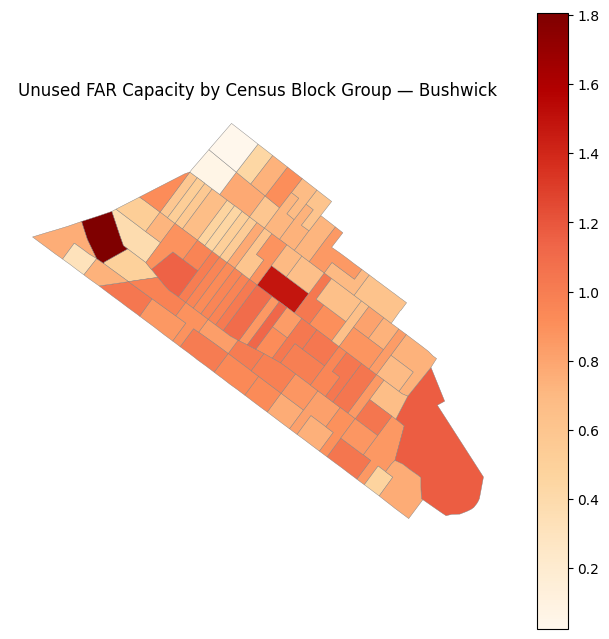

In [6]:
# CELL 6 — Map: FAR gap by block group. (Boilerplate.)
#
# Merges the aggregated FAR gap back onto the block group polygons and
# plots a choropleth — same idea as Day 16, but block-group resolution
# instead of zip code.

gdf_bg_far = gdf_bg.merge(df_bg_far, on='GEOID', how='left')

gdf_bg_bushwick = gdf_bg_far[gdf_bg_far['far_gap'].notna()]

fig, ax = plt.subplots(figsize=(8, 8))
gdf_bg_bushwick.plot(
    column='far_gap',
    cmap='OrRd',
    linewidth=0.3,
    edgecolor='grey',
    legend=True,
    ax=ax
)
ax.set_title('Unused FAR Capacity by Census Block Group — Bushwick')
ax.set_axis_off()
plt.show()


**Critical thinking pause:**
- Compare this map to Day 16's zip-code choropleth. Does the block-group version reveal anything the zip-code version hid — pockets of high or low FAR gap within a single zip code?
- Some block groups might have only 1–2 PLUTO lots. What does that do to the reliability of their average `far_gap`, compared to a block group with 40 lots?
- You reprojected `gdf_pluto` to match `gdf_bg`'s CRS rather than the other way around. Would it have mattered which direction you reprojected? What would break if you'd forgotten this step entirely?
- Zip codes are a postal delivery construct, not a Census geography — they don't nest cleanly inside block groups, tracts, or even counties. Now that you've joined by actual location instead, what's one analysis from Days 13–17 you'd trust *more* using this block-group version?


*(Write your answers here)*

## Day 18 Recap

| What you did | Why it matters |
|---|---|
| Downloaded TIGER/Line block group boundaries | Real Census geometry, not just a data table |
| Built a GeoDataFrame from lat/lon | Turned plain numbers into points geopandas can reason about spatially |
| Checked and aligned CRS before joining | Mismatched CRS fails silently — wrong joins, no error |
| Spatial join (`sjoin`) instead of `merge` | Joined on geometry ("is this point inside this polygon") instead of a shared key column |
| Aggregated lot-level data to block-group level | Same groupby skill, finer geography than zip code |

## Close-out

In your own words: what's the difference between a regular merge and a spatial join, and why did you need to check the CRS before doing one?

### What's coming on Day 19
TBD — pick the next thread: transit access (B38 GTFS headways vs. displacement risk), or ownership chains (ACRIS — who owns multiple Bushwick lots, and does that correlate with risk score)?
